# 01 — Problème, données & premiers signaux

> **Question :** A-t-on des données suffisamment fiables pour étudier le prix du maïs CBOT ?

| | |
|---|---|
| **Hypothèse** | Les données disponibles couvrent les drivers fondamentaux, mais avec des lacunes importantes |
| **Données** | features.parquet — 249 variables, 2000-2025 |
| **Intérêt agricole** | Comprendre quelles données sont disponibles et fiables avant de modéliser |

In [1]:
import sys, warnings
sys.path.insert(0, '../../../src')
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
ROOT = __import__('pathlib').Path('../../../')
from mais.research.data_quality import load_study_data, compute_coverage, compute_correlations, leakage_summary
feat, tgt, fac = load_study_data()
print(f"Features : {feat.shape}  |  Targets : {tgt.shape}")
print(f"Période  : {feat['Date'].min().date()} → {feat['Date'].max().date()}")

2026-05-15 14:14:11,203 INFO mais.research.data_quality | 2026-05-15T12:14:11.203492Z [info     ] data_loaded                    features=(6192, 276) targets=(6192, 25)


Features : (6192, 276)  |  Targets : (6192, 25)
Période  : 2000-10-25 → 2025-07-25


## 1. Couverture temporelle par classe de données

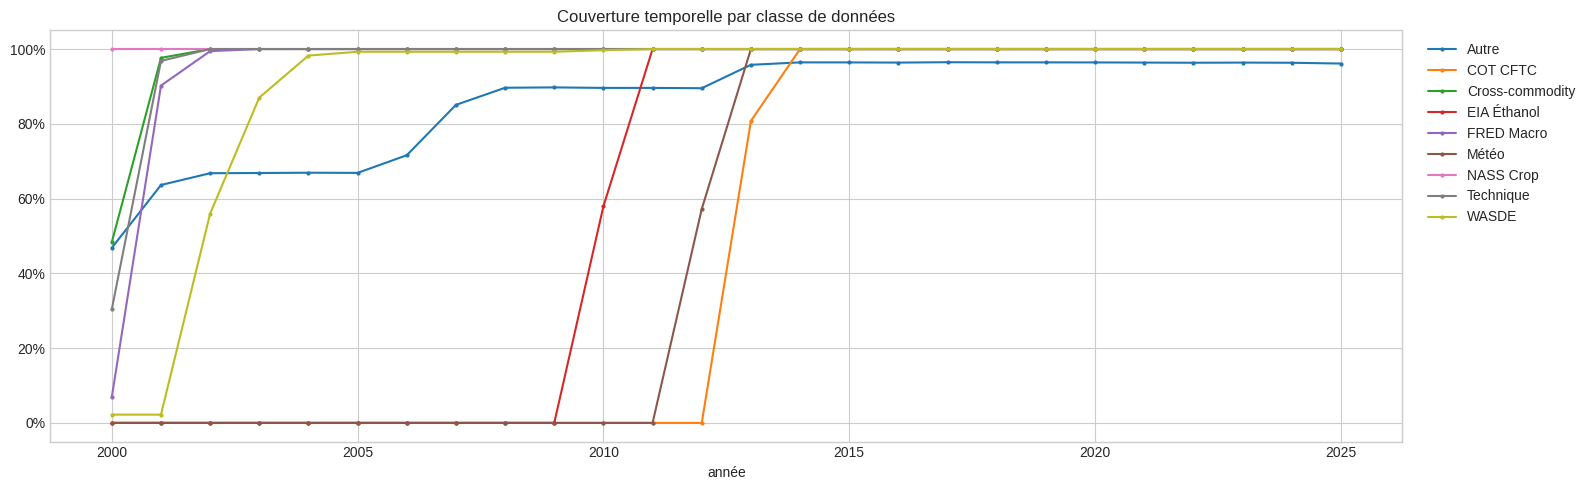

In [2]:
cov = compute_coverage(feat)
pivot = cov.groupby(['année','famille'])['couverture'].mean().unstack(fill_value=0)
ax = pivot.plot(figsize=(16, 5), marker='o', markersize=2, lw=1.5)
ax.set_title('Couverture temporelle par classe de données')
ax.yaxis.set_major_formatter(__import__('matplotlib').ticker.PercentFormatter(1))
ax.legend(bbox_to_anchor=(1.01,1), loc='upper left')
plt.tight_layout()
plt.show()

## 2. Corrélations avec le rendement h=20j

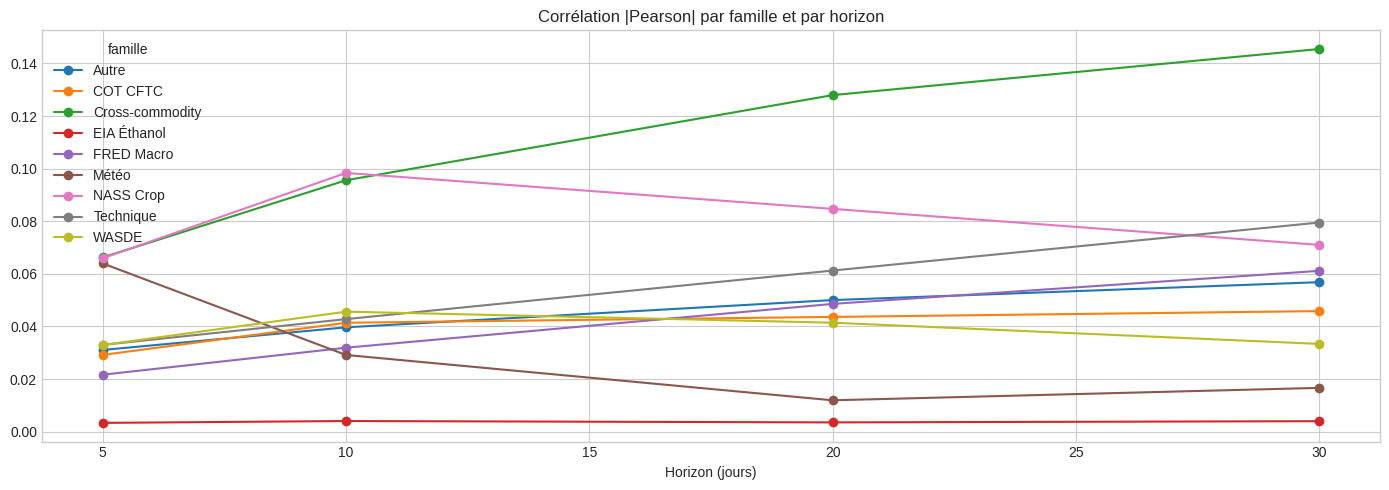

In [3]:
from mais.research.data_quality import compute_correlations_by_horizon
corr_h = compute_correlations_by_horizon(feat, tgt)
pivot_c = corr_h.pivot(index='horizon', columns='famille', values='pearson')
ax = pivot_c.plot(marker='o', figsize=(14, 5))
ax.set_title('Corrélation |Pearson| par famille et par horizon')
ax.set_xlabel('Horizon (jours)')
plt.tight_layout()
plt.show()

## 3. Audit anti-leakage

In [4]:
summary = leakage_summary()
print(f"Anti-leakage audit : {summary}")

Anti-leakage audit : {'status': 'pass', 'violations': 0, 'checks': {}}


## 4. Conclusion

Le dataset couvre 25 ans (2000-2025) avec ~249 variables. 
Points critiques :
- COT disponible seulement depuis ~2013 → deux périodes de données
- NASS crop progress saisonnier (mai-oct seulement)  
- EIA éthanol présent mais partiel
- WASDE = source la plus complète sur toute la période

→ **Décision :** On garde tout, mais on signale les lacunes dans chaque analyse. 
On crée un indicateur `cot_available` pour distinguer les deux ères de données.